<a href="https://colab.research.google.com/github/oldguy773/FAA-Wildlife-Strike-Analysis/blob/main/Wildlifestrikes_on_Aircraft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
os.environ['KAGGLE_USERNAME'] = 'adharvaturaga'
os.environ['KAGGLE_KEY'] = 'KGAT_47e0590e2187a777dd0d96d2ceea7f0c'
!kaggle datasets download -d faa/wildlife-strikes
!unzip wildlife-strikes.zip

Dataset URL: https://www.kaggle.com/datasets/faa/wildlife-strikes
License(s): CC0-1.0
wildlife-strikes.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  wildlife-strikes.zip
replace database.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: database.csv            


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv('database.csv', low_memory= False)
print(df.shape)
df.head()

(174104, 66)


,Record ID,Incident Year,Incident Month,Incident Day,Operator ID,Operator,Aircraft,Aircraft Type,Aircraft Make,Aircraft Model,...,Fuselage Strike,Fuselage Damage,Landing Gear Strike,Landing Gear Damage,Tail Strike,Tail Damage,Lights Strike,Lights Damage,Other Strike,Other Damage
0,127128,1990,1,1,DAL,DELTA AIR LINES,B-757-200,A,148,26,...,0,0,0,0,1,1,0,0,0,0
1,129779,1990,1,1,HAL,HAWAIIAN AIR,DC-9,A,583,90,...,0,0,0,0,0,0,0,0,1,0
2,129780,1990,1,2,UNK,UNKNOWN,UNKNOWN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,2258,1990,1,3,MIL,MILITARY,A-10A,A,345,NaN,...,0,0,0,0,0,0,0,0,0,0
4,2257,1990,1,3,MIL,MILITARY,F-16,A,561,NaN,...,0,0,0,0,0,0,0,0,0,0


# Data Anlaysis

## The DataSet

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174104 entries, 0 to 174103
Data columns (total 66 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Record ID             174104 non-null  int64  
 1   Incident Year         174104 non-null  int64  
 2   Incident Month        174104 non-null  int64  
 3   Incident Day          174104 non-null  int64  
 4   Operator ID           174104 non-null  object 
 5   Operator              174104 non-null  object 
 6   Aircraft              174104 non-null  object 
 7   Aircraft Type         133074 non-null  object 
 8   Aircraft Make         131051 non-null  object 
 9   Aircraft Model        122439 non-null  object 
 10  Aircraft Mass         127320 non-null  float64
 11  Engine Make           123434 non-null  float64
 12  Engine Model          121988 non-null  object 
 13  Engines               127342 non-null  float64
 14  Engine Type           127282 non-null  object 
 15  

## The Different Categories Present

In [9]:
print(df.columns.tolist())

['Record ID', 'Incident Year', 'Incident Month', 'Incident Day', 'Operator ID', 'Operator', 'Aircraft', 'Aircraft Type', 'Aircraft Make', 'Aircraft Model', 'Aircraft Mass', 'Engine Make', 'Engine Model', 'Engines', 'Engine Type', 'Engine1 Position', 'Engine2 Position', 'Engine3 Position', 'Engine4 Position', 'Airport ID', 'Airport', 'State', 'FAA Region', 'Warning Issued', 'Flight Phase', 'Visibility', 'Precipitation', 'Height', 'Speed', 'Distance', 'Species ID', 'Species Name', 'Species Quantity', 'Flight Impact', 'Fatalities', 'Injuries', 'Aircraft Damage', 'Radome Strike', 'Radome Damage', 'Windshield Strike', 'Windshield Damage', 'Nose Strike', 'Nose Damage', 'Engine1 Strike', 'Engine1 Damage', 'Engine2 Strike', 'Engine2 Damage', 'Engine3 Strike', 'Engine3 Damage', 'Engine4 Strike', 'Engine4 Damage', 'Engine Ingested', 'Propeller Strike', 'Propeller Damage', 'Wing or Rotor Strike', 'Wing or Rotor Damage', 'Fuselage Strike', 'Fuselage Damage', 'Landing Gear Strike', 'Landing Gear Da

### Aircraft Damage
This shows at how many instances the aircraft was damaged in a strike

In [10]:
print(df['Aircraft Damage'].value_counts())

Aircraft Damage
0    159135
1     14969
Name: count, dtype: int64


### Flight Phase
Shows at what phase of the flight the strikes occured the most

In [11]:
print(df['Flight Phase'].value_counts())

Flight Phase
APPROACH        48275
TAKEOFF RUN     21953
LANDING ROLL    20762
CLIMB           19692
DESCENT          3174
EN ROUTE         2989
LANDING           626
TAXI              397
DEPARTURE         369
LOCAL             316
ARRIVAL           154
PARKED             95
Name: count, dtype: int64


### Incident Year
Shows at what years were the strikes most prevalent

<Axes: title={'center': 'Strikes per year'}, xlabel='Incident Year'>

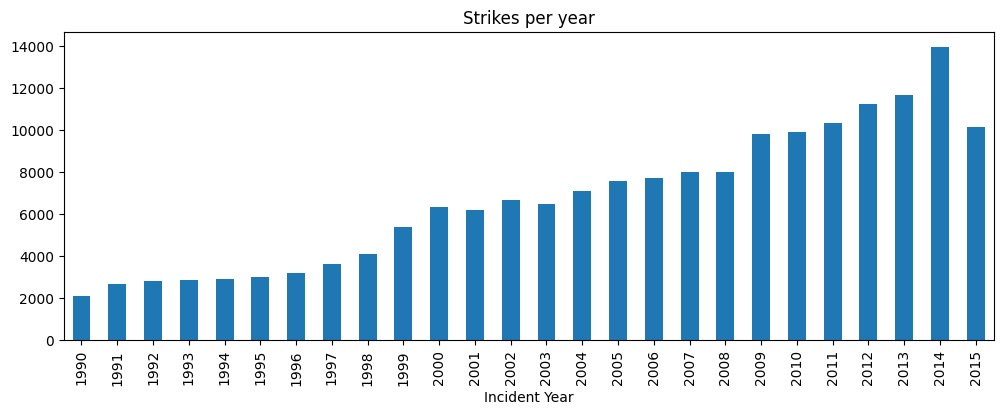

In [12]:
df['Incident Year'].value_counts().sort_index().plot(kind='bar', figsize=(12,4), title='Strikes per year')

### Species Name
This shows what species were the most involved in the strikes

In [13]:
print(df['Species Name'].value_counts().head(10))

Species Name
UNKNOWN MEDIUM BIRD    38531
UNKNOWN SMALL BIRD     32981
MOURNING DOVE           7653
GULL                    6580
UNKNOWN BIRD            6400
KILLDEER                4562
AMERICAN KESTREL        4476
BARN SWALLOW            4215
HORNED LARK             3952
EUROPEAN STARLING       3915
Name: count, dtype: int64


### Damage Rate by Flight Phase


In [14]:
df.groupby('Flight Phase')['Aircraft Damage'].value_counts(normalize=True).unstack()

Aircraft Damage,0,1
Flight Phase,,
APPROACH,0.903925,0.096075
ARRIVAL,0.948052,0.051948
CLIMB,0.837650,0.162350
DEPARTURE,0.964770,0.035230
DESCENT,0.798677,0.201323
EN ROUTE,0.613583,0.386417
LANDING,0.952077,0.047923
LANDING ROLL,0.926693,0.073307
LOCAL,0.943038,0.056962


### Damage Rate per Species

In [15]:
damage_by_species = df.groupby('Species Name')['Aircraft Damage'].apply(
    lambda x: (x == 1).sum() / len(x) * 100
).sort_values(ascending=False).head(20).to_frame(name='Damage %')

damage_by_species.style.background_gradient(cmap='Reds')

,Damage %
Species Name,
YELLOW-LEGGED GULL,100.000000
WHOOPING CRANE,100.000000
SOUTHERN LAPWING,100.000000
AUSTRALIAN PELICAN,100.000000
WAPITI (ELK),100.000000
WHITE-BELLIED SEA-EAGLE,100.000000
WHITE STORK,100.000000
TRUMPETER SWAN,100.000000
ROCK PTARMIGAN,100.000000


### Total Strikes per Species And Damage Rate

In [16]:
species_stats = df.groupby('Species Name').agg(
    total_strikes=('Aircraft Damage', 'count'),
    damage_rate=('Aircraft Damage', lambda x: (x == 1).sum() / len(x) * 100)
).sort_values('total_strikes', ascending=False).head(20)

species_stats.style.background_gradient(cmap='Reds')

,total_strikes,damage_rate
Species Name,,
UNKNOWN MEDIUM BIRD,38531,11.011912
UNKNOWN SMALL BIRD,32981,2.886510
MOURNING DOVE,7653,2.717888
GULL,6580,16.641337
UNKNOWN BIRD,6400,6.953125
KILLDEER,4562,1.183691
AMERICAN KESTREL,4476,0.625559
BARN SWALLOW,4215,0.450771
HORNED LARK,3952,0.809717


### Ingestion Rates and Damage Rates per Engine

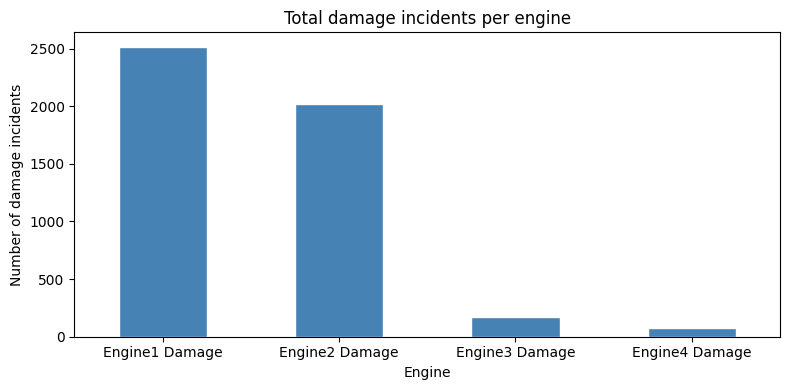

In [32]:
# which engine gets damaged most often
engine_damage = df[['Engine1 Damage', 'Engine2 Damage',
                     'Engine3 Damage', 'Engine4 Damage']].sum()

engine_damage.plot(
    kind='bar',
    figsize=(8, 4),
    title='Total damage incidents per engine',
    color='steelblue',
    edgecolor='white'
)
plt.ylabel('Number of damage incidents')
plt.xlabel('Engine')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

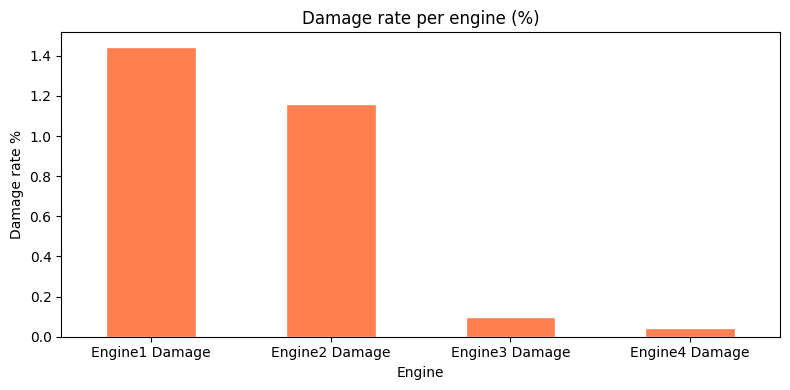

In [31]:
# what % of strikes damaged each engine
engine_rate = df[['Engine1 Damage', 'Engine2 Damage',
                   'Engine3 Damage', 'Engine4 Damage']].mean() * 100

engine_rate.plot(
    kind='bar',
    figsize=(8, 4),
    title='Damage rate per engine (%)',
    color='coral',
    edgecolor='white'
)
plt.ylabel('Damage rate %')
plt.xlabel('Engine')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
print(df['Engine Ingested'].value_counts())
print(f"\nIngestion rate: {df['Engine Ingested'].mean() * 100:.1f}%")

Engine Ingested
0    164497
1      9607
Name: count, dtype: int64

Ingestion rate: 5.5%


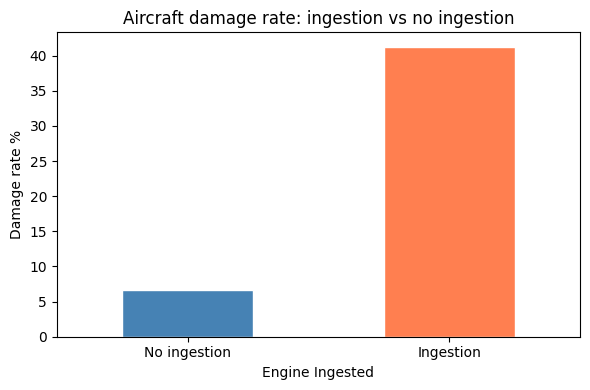

In [38]:
ingestion_damage = df.groupby('Engine Ingested')['Aircraft Damage'].mean() * 100

ingestion_damage.plot(
    kind='bar',
    figsize=(6, 4),
    title='Aircraft damage rate: ingestion vs no ingestion',
    color=['steelblue', 'coral'],
    edgecolor='white'
)
plt.ylabel('Damage rate %')
plt.xticks([0, 1], ['No ingestion', 'Ingestion'], rotation=0)
plt.tight_layout()
plt.show()

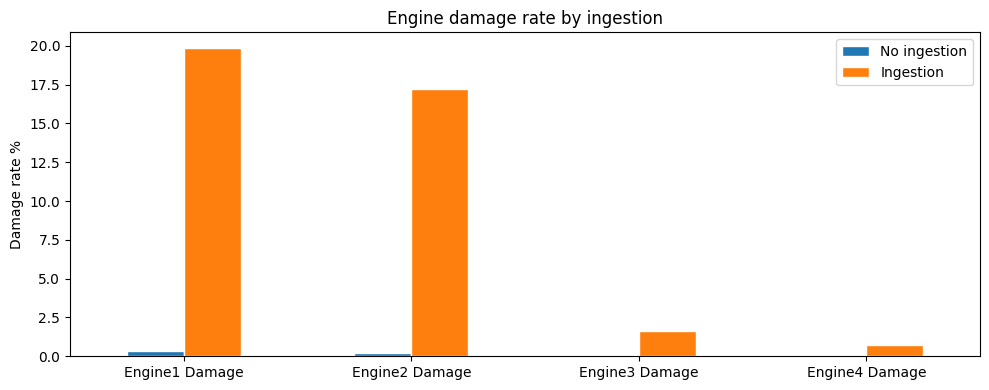

In [39]:
engine_cols = ['Engine1 Damage', 'Engine2 Damage', 'Engine3 Damage', 'Engine4 Damage']

ingestion_engine = df.groupby('Engine Ingested')[engine_cols].mean() * 100

ingestion_engine.T.plot(
    kind='bar',
    figsize=(10, 4),
    title='Engine damage rate by ingestion',
    edgecolor='white'
)
plt.ylabel('Damage rate %')
plt.xticks(rotation=0)
plt.legend(['No ingestion', 'Ingestion'])
plt.tight_layout()
plt.show()

# Data Visualization

## Strikes by Flight Phase

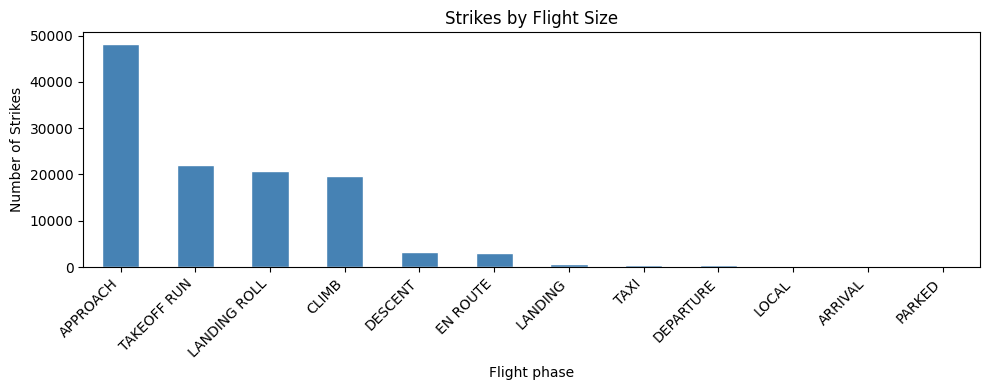

In [17]:
df['Flight Phase'].value_counts().plot(kind='bar', figsize=(10,4), title='Strikes by Flight Size', color='steelblue', edgecolor='white')
plt.ylabel("Number of Strikes")
plt.xlabel("Flight phase")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Damage Rate per Species


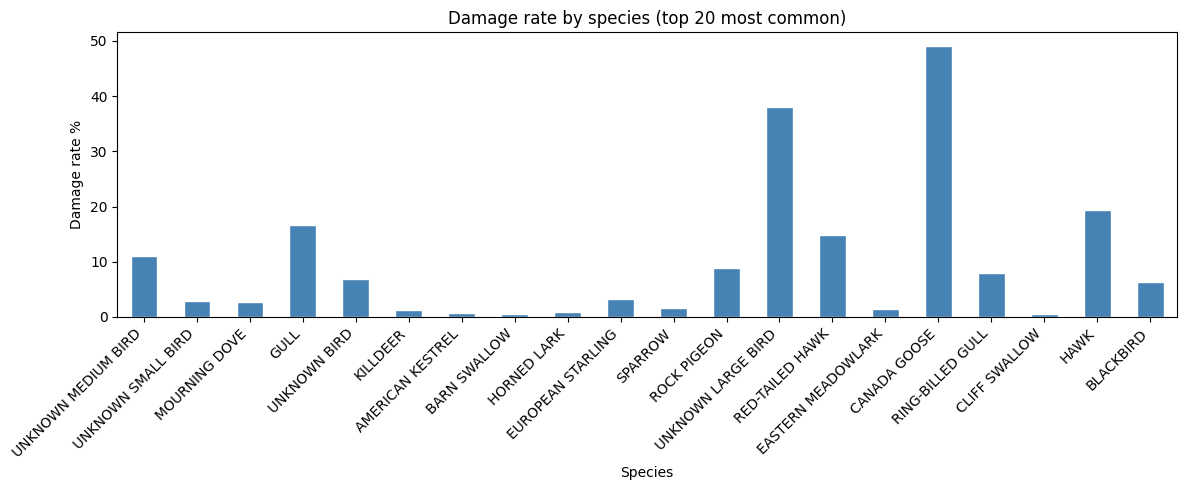

In [18]:
species_stats = df.groupby('Species Name').agg(
    total_strikes=('Aircraft Damage', 'count'),
    damage_rate=('Aircraft Damage', lambda x: (x == 1).sum() / len(x) * 100)
).sort_values('total_strikes', ascending=False).head(20)

species_stats['damage_rate'].plot(
    kind='bar',
    figsize=(12, 5),
    title='Damage rate by species (top 20 most common)',
    color='steelblue',
    edgecolor='white'
)
plt.ylabel('Damage rate %')
plt.xlabel('Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
print(df[df['Species Name'].isnull()])

        Record ID  Incident Year  Incident Month  Incident Day Operator ID  \
150991      17609           2014               3            19         MIL   
151078      17610           2014               3            24         MIL   
152551      17618           2014               5             9         MIL   
153122      17624           2014               5            22         MIL   
153849      17627           2014               6            11         MIL   
...           ...            ...             ...           ...         ...   
172729     366790           2015               9             4         AAL   
172955      17953           2015               9             9         MIL   
173045     367336           2015               9            10         PHM   
173067      17954           2015               9            10         MIL   
173151     367249           2015               9            12         FDX   

                 Operator       Aircraft Aircraft Type Aircraft

# Data Cleaning

## Finiding Missing Data

In [20]:
# check missing values
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values(ascending=False).to_frame(name='Missing %')
missing.style.background_gradient(cmap='Reds')

,Missing %
Injuries,99.868469
Fatalities,99.675481
Engine4 Position,98.224050
Engine3 Position,93.303428
Speed,59.071589
Warning Issued,56.107844
Precipitation,49.270551
Flight Impact,42.870353
Distance,42.727910
Height,40.451110


## Cleaning the data

In [28]:
# drop irrelevant and high-missing columns
df = df.drop(columns=[
    'Aircraft Type',
    'Aircraft Make',
    'Aircraft Model',
    'Engine Make',
    'Engine Model',
    'Engines',
    'Engine Type',
    'Engine1 Position',
    'Engine2 Position',
    'Engine3 Position',
    'Engine4 Position',
    'Warning Issued',
    'Speed',
    'Fatalities',
    'Injuries',
    'Operator',
    'Aircraft',
])

# fill missing values
df['Flight Phase'] = df['Flight Phase'].fillna(df['Flight Phase'].mode()[0])
df['Precipitation'] = df['Precipitation'].fillna(df['Precipitation'].mode()[0])
df['Visibility'] = df['Visibility'].fillna(df['Visibility'].mode()[0])
df['Aircraft Mass'] = df['Aircraft Mass'].fillna(df['Aircraft Mass'].mode()[0])
df['Species Quantity'] = df['Species Quantity'].fillna(df['Species Quantity'].mode()[0])
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Distance'] = df['Distance'].fillna(df['Distance'].median())
df['Species Name'] = df['Species Name'].fillna('Unknown')

# check result
print(df.shape)
print(df.columns.tolist())
missing = df.isnull().sum()
print(missing[missing > 0])

(174104, 31)
['Incident Year', 'Incident Month', 'Incident Day', 'Aircraft Mass', 'Airport', 'State', 'FAA Region', 'Flight Phase', 'Visibility', 'Precipitation', 'Height', 'Distance', 'Species Name', 'Species Quantity', 'Flight Impact', 'Aircraft Damage', 'Radome Damage', 'Windshield Damage', 'Nose Damage', 'Engine1 Damage', 'Engine2 Damage', 'Engine3 Damage', 'Engine4 Damage', 'Engine Ingested', 'Propeller Damage', 'Wing or Rotor Damage', 'Fuselage Damage', 'Landing Gear Damage', 'Tail Damage', 'Lights Damage', 'Other Damage']
Airport            290
State            21976
FAA Region       18902
Flight Impact    74639
dtype: int64


In [22]:
df = df.drop(columns=[
    'Radome Strike',
    'Windshield Strike',
    'Nose Strike',
    'Engine1 Strike',
    'Engine2 Strike',
    'Engine3 Strike',
    'Engine4 Strike',
    'Propeller Strike',
    'Wing or Rotor Strike',
    'Fuselage Strike',
    'Landing Gear Strike',
    'Tail Strike',
    'Lights Strike',
    'Other Strike',
])

print(df.shape)
print(df.columns.tolist())

(174104, 48)
['Incident Year', 'Incident Month', 'Incident Day', 'Operator', 'Aircraft', 'Aircraft Type', 'Aircraft Make', 'Aircraft Model', 'Aircraft Mass', 'Engine Make', 'Engine Model', 'Engines', 'Engine Type', 'Engine1 Position', 'Engine2 Position', 'Engine3 Position', 'Engine4 Position', 'Airport', 'State', 'FAA Region', 'Warning Issued', 'Flight Phase', 'Visibility', 'Precipitation', 'Height', 'Speed', 'Distance', 'Species Name', 'Species Quantity', 'Flight Impact', 'Fatalities', 'Injuries', 'Aircraft Damage', 'Radome Damage', 'Windshield Damage', 'Nose Damage', 'Engine1 Damage', 'Engine2 Damage', 'Engine3 Damage', 'Engine4 Damage', 'Engine Ingested', 'Propeller Damage', 'Wing or Rotor Damage', 'Fuselage Damage', 'Landing Gear Damage', 'Tail Damage', 'Lights Damage', 'Other Damage']


In [ ]:
df = df.drop(columns=['Incident Day'])
print(df.shape)

In [23]:
print(df.columns.tolist())

['Incident Year', 'Incident Month', 'Incident Day', 'Operator', 'Aircraft', 'Aircraft Type', 'Aircraft Make', 'Aircraft Model', 'Aircraft Mass', 'Engine Make', 'Engine Model', 'Engines', 'Engine Type', 'Engine1 Position', 'Engine2 Position', 'Engine3 Position', 'Engine4 Position', 'Airport', 'State', 'FAA Region', 'Warning Issued', 'Flight Phase', 'Visibility', 'Precipitation', 'Height', 'Speed', 'Distance', 'Species Name', 'Species Quantity', 'Flight Impact', 'Fatalities', 'Injuries', 'Aircraft Damage', 'Radome Damage', 'Windshield Damage', 'Nose Damage', 'Engine1 Damage', 'Engine2 Damage', 'Engine3 Damage', 'Engine4 Damage', 'Engine Ingested', 'Propeller Damage', 'Wing or Rotor Damage', 'Fuselage Damage', 'Landing Gear Damage', 'Tail Damage', 'Lights Damage', 'Other Damage']


In [24]:
print(df['Aircraft Damage'].value_counts())

Aircraft Damage
0    159135
1     14969
Name: count, dtype: int64


# Feature Enginnering

## Understanding Unique Values in the Data Set


In [29]:
print(df.dtypes)

Incident Year             int64
Incident Month            int64
Incident Day              int64
Aircraft Mass           float64
Airport                  object
State                    object
FAA Region               object
Flight Phase             object
Visibility               object
Precipitation            object
Height                  float64
Distance                float64
Species Name             object
Species Quantity         object
Flight Impact            object
Aircraft Damage           int64
Radome Damage             int64
Windshield Damage         int64
Nose Damage               int64
Engine1 Damage            int64
Engine2 Damage            int64
Engine3 Damage            int64
Engine4 Damage            int64
Engine Ingested           int64
Propeller Damage          int64
Wing or Rotor Damage      int64
Fuselage Damage           int64
Landing Gear Damage       int64
Tail Damage               int64
Lights Damage             int64
Other Damage              int64
dtype: o

In [26]:
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    print(f"{col}: {df[col].nunique()} unique values")



Operator: 533 unique values
Aircraft: 656 unique values
Aircraft Type: 3 unique values
Aircraft Make: 95 unique values
Aircraft Model: 63 unique values
Engine Model: 64 unique values
Engine Type: 9 unique values
Engine1 Position: 8 unique values
Engine3 Position: 5 unique values
Airport: 2226 unique values
State: 62 unique values
FAA Region: 15 unique values
Warning Issued: 4 unique values
Flight Phase: 12 unique values
Visibility: 5 unique values
Precipitation: 8 unique values
Species Name: 716 unique values
Species Quantity: 4 unique values
Flight Impact: 6 unique values


In [27]:
print(df.columns.tolist())


['Incident Year', 'Incident Month', 'Incident Day', 'Operator', 'Aircraft', 'Aircraft Type', 'Aircraft Make', 'Aircraft Model', 'Aircraft Mass', 'Engine Make', 'Engine Model', 'Engines', 'Engine Type', 'Engine1 Position', 'Engine2 Position', 'Engine3 Position', 'Engine4 Position', 'Airport', 'State', 'FAA Region', 'Warning Issued', 'Flight Phase', 'Visibility', 'Precipitation', 'Height', 'Speed', 'Distance', 'Species Name', 'Species Quantity', 'Flight Impact', 'Fatalities', 'Injuries', 'Aircraft Damage', 'Radome Damage', 'Windshield Damage', 'Nose Damage', 'Engine1 Damage', 'Engine2 Damage', 'Engine3 Damage', 'Engine4 Damage', 'Engine Ingested', 'Propeller Damage', 'Wing or Rotor Damage', 'Fuselage Damage', 'Landing Gear Damage', 'Tail Damage', 'Lights Damage', 'Other Damage']


In [41]:
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    print(f"{col}: {df[col].nunique()} unique values")


Airport: 2226 unique values
State: 62 unique values
FAA Region: 15 unique values
Flight Phase: 12 unique values
Visibility: 5 unique values
Precipitation: 8 unique values
Species Name: 716 unique values
Species Quantity: 4 unique values
Flight Impact: 6 unique values


## Labeling the Data

In [43]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
for col in ['Airport','Species Name','State']:
  df[col]= le.fit_transform(df[col])
print('labeling done')

labeling done


In [44]:
df = pd.get_dummies(df, columns=[
    'FAA Region',
    'Flight Phase',
    'Precipitation',
    'Flight Impact',
    'Visibility',
    'Species Quantity'
])

print(df.shape)

(174104, 75)


In [45]:
# check no text columns remain
print("Text columns left:", df.select_dtypes(include='object').columns.tolist())

# check no missing values
missing = df.isnull().sum()
print("Missing values:", missing[missing > 0])

# check shape
print("Shape:", df.shape)

Text columns left: []
Missing values: Series([], dtype: int64)
Shape: (174104, 75)


# Building the Model

## Splitting Features and target

In [46]:
# X is everything except the target
X = df.drop(columns=['Aircraft Damage'])

# y is the target column we're trying to predict
y = df['Aircraft Damage']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (174104, 74)
y shape: (174104,)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 139283
Testing rows: 34821


## The Model

In [48]:
from sklearn.ensemble import RandomForestClassifier

# create the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# train it
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [49]:
y_pred = model.predict(X_test)
print("Predictions done!")

Predictions done!


In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# overall accuracy
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

Accuracy: 99.84492116826054 %


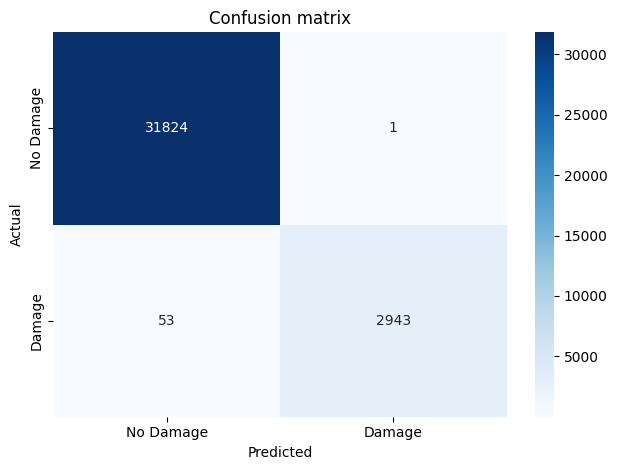

In [51]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Damage', 'Damage'],
    yticklabels=['No Damage', 'Damage']
)
plt.title('Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [52]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(15))

Wing or Rotor Damage    0.224120
Engine1 Damage          0.116856
Engine2 Damage          0.091181
Radome Damage           0.083671
Other Damage            0.072852
Nose Damage             0.046789
Windshield Damage       0.045428
Landing Gear Damage     0.038990
Lights Damage           0.034262
Tail Damage             0.030233
Engine Ingested         0.030037
Fuselage Damage         0.028019
Aircraft Mass           0.015949
Propeller Damage        0.014877
Species Name            0.014422
dtype: float64


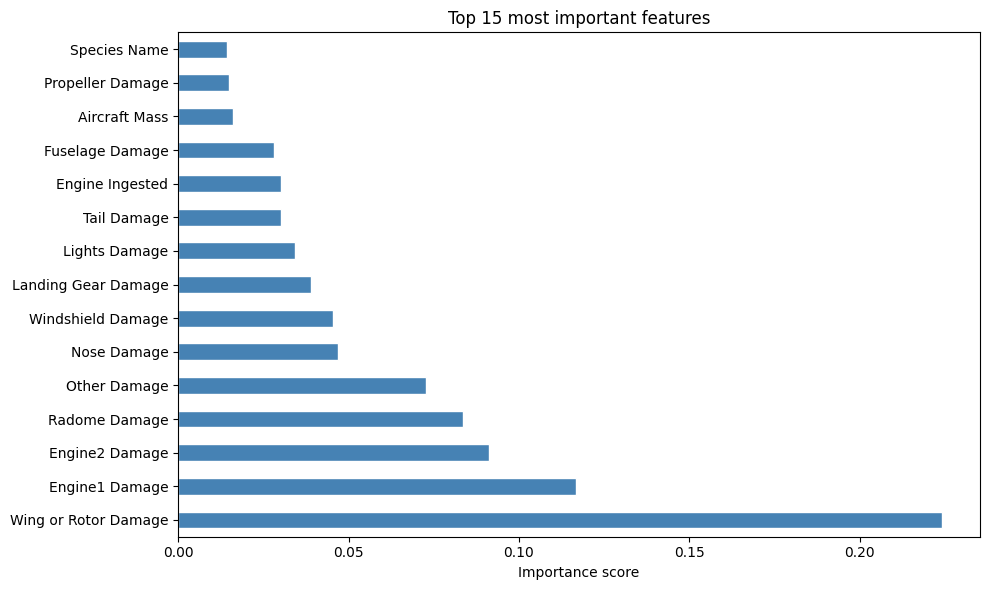

In [53]:
importance.head(15).plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 15 most important features',
    color='steelblue',
    edgecolor='white'
)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()